# Differential Expression: Unbiased

In this notebook, I run broad-class pseudobulk differential expression across the full gene space and then inspect the saved result tables with volcano plots, heatmaps, donor-level gene plots, and ranked DEG summaries. The workflow is intentionally broad-class only: `Excitatory`, `Inhibitory`, `Glia`, and `Vascular`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

sys.path.append(str(Path("../src").resolve()))
from c9_snrnaseq.io_utils import PROJECT_ROOT


## 1. Load The Broad-Class Pseudobulk Source Object

I load the broad-class pseudobulk source object prepared in notebook 10. This object contains the raw-count matrix together with the current broad Harmony labels.


In [2]:
RESULTS_DIR = PROJECT_ROOT / "results"
DE_BROAD_DIR = RESULTS_DIR / "de_pseudobulk_broad"
FIGURES_DIR = RESULTS_DIR / "figures"

for d in [RESULTS_DIR, DE_BROAD_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

adata_merged_pb = sc.read_h5ad(PROJECT_ROOT / "data/processed/merged/adata_merged_pb.h5ad")

print(adata_merged_pb.shape)
print("Has counts:", "counts" in adata_merged_pb.layers)
print("Has cell_class_major_harmony:", "cell_class_major_harmony" in adata_merged_pb.obs.columns)
print(adata_merged_pb.obs["cell_class_major_harmony"].value_counts(dropna=False))


(88883, 61552)
Has counts: True
Has cell_class_major_harmony: True
cell_class_major_harmony
Glia          65529
Excitatory    16001
Inhibitory     6717
Vascular        636
Name: count, dtype: int64


In [3]:
broad_main_classes = [
    label for label in ["Excitatory", "Inhibitory", "Glia", "Vascular"]
    if label in set(adata_merged_pb.obs["cell_class_major_harmony"].dropna().astype(str))
]

pairwise_tests = [
    ("Control", "sALS"),
    ("Control", "c9ALS"),
    ("sALS", "c9ALS"),
]

print("Broad classes analysed:", broad_main_classes)


Broad classes analysed: ['Excitatory', 'Inhibitory', 'Glia', 'Vascular']


## 2. Define Pseudobulk And DE Helper Functions

I aggregate raw counts at donor level within each broad class, then run pairwise DESeq2 comparisons between conditions across the full gene space.


In [4]:
def pseudobulk_by_sample(
    adata,
    group_value,
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
    layer="counts",
):
    sub = adata[adata.obs[groupby_col].astype(str) == str(group_value)].copy()
    if sub.n_obs == 0:
        raise ValueError(f"No cells found for {groupby_col}={group_value!r}.")

    cell_counts = sub.obs["sample"].astype(str).value_counts()
    keep_samples = cell_counts[cell_counts >= min_cells_per_sample].index.tolist()
    if not keep_samples:
        raise ValueError(
            f"No samples retained for {groupby_col}={group_value!r} "
            f"with min_cells_per_sample={min_cells_per_sample}."
        )

    sub = sub[sub.obs["sample"].astype(str).isin(keep_samples)].copy()
    sample_order = sorted(sub.obs["sample"].astype(str).unique())
    pb_counts = []
    pb_meta = []

    for samp in sample_order:
        ss = sub[sub.obs["sample"].astype(str) == samp]
        x = ss.layers[layer] if layer in ss.layers else ss.X
        if hasattr(x, "toarray"):
            x = x.toarray()

        pb_counts.append(np.asarray(x.sum(axis=0)).ravel())
        pb_meta.append({
            "sample": samp,
            "condition": ss.obs["condition"].astype(str).iloc[0],
            "group_value": str(group_value),
            "groupby_col": groupby_col,
            "n_cells": ss.n_obs,
        })

    counts_df = pd.DataFrame(pb_counts, index=sample_order, columns=sub.var_names)
    meta_df = pd.DataFrame(pb_meta).set_index("sample")
    return counts_df, meta_df


def run_pairwise_deseq(counts_df, meta_df, group_a, group_b):
    keep = meta_df["condition"].isin([group_a, group_b])
    counts_use = counts_df.loc[keep].copy()
    meta_use = meta_df.loc[keep].copy()

    counts_use = counts_use.round().astype(int)

    dds = DeseqDataSet(
        counts=counts_use,
        metadata=meta_use,
        design="~condition",
        refit_cooks=True,
    )
    dds.deseq2()

    stats = DeseqStats(dds, contrast=["condition", group_b, group_a])
    summary_res = stats.summary()

    if isinstance(summary_res, pd.DataFrame):
        res = summary_res.copy()
    elif hasattr(stats, "results_df"):
        res = stats.results_df.copy()
    else:
        result_attrs = [attr for attr in dir(stats) if "result" in attr.lower()]
        raise AttributeError(
            "Could not retrieve DESeq2 results from DeseqStats. "
            f"Available result-like attributes: {result_attrs}"
        )

    res["gene"] = res.index
    return res


## 3. Regeneration Of Full-Gene DE Tables (Just once, then optional)

I usually inspect previously saved full-gene DE result tables. If I need to refresh them, I can set `regenerate_full_de = True` and rerun this section.


In [ ]:
regenerate_full_de = False

if regenerate_full_de:
    broad_de_results = {}
    skipped_groups = []

    for ct in broad_main_classes:
        try:
            counts_df, meta_df = pseudobulk_by_sample(
                adata_merged_pb,
                group_value=ct,
                groupby_col="cell_class_major_harmony",
                min_cells_per_sample=20,
                layer="counts",
            )
        except ValueError as e:
            skipped_groups.append((ct, str(e)))
            print(f"Skipping {ct}: {e}")
            continue

        for g1, g2 in pairwise_tests:
            res = run_pairwise_deseq(counts_df, meta_df, g1, g2)
            res.to_csv(DE_BROAD_DIR / f"{ct}_{g1}_vs_{g2}.csv", index=False)
            broad_de_results[(ct, g1, g2)] = res

    print("Skipped groups:", skipped_groups)
else:
    print("Using previously saved full-gene DE result tables.")


Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 2.25 seconds.

Fitting dispersion trend curve...
... done in 0.43 seconds.

Fitting MAP dispersions...
... done in 2.69 seconds.

Fitting LFCs...
... done in 2.23 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.47 seconds.



Log2 fold change & Wald test p-value: condition sALS vs Control
                   baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TNFRSF4            6.828566       -1.585594  0.613716 -2.583597  0.009778   
TNFRSF18          26.313478       -1.203909  0.480687 -2.504559  0.012260   
ATAD3B           282.685516       -0.490433  0.208421 -2.353084  0.018618   
ENSG00000260179    1.396937       -0.715959  1.329215 -0.538633  0.590140   
ENSG00000234396   23.076513       -0.506040  0.371845 -1.360887  0.173549   
...                     ...             ...       ...       ...       ...   
ENSG00000271254   66.519207        0.520868  0.276199  1.885841  0.059316   
U1-4               0.123835        1.447701  3.843067  0.376705  0.706393   
ENSG00000268674    0.075409       -0.392627  3.893686 -0.100837  0.919680   
ENSG00000277475    0.106132       -0.392627  3.893686 -0.100837  0.919680   
U1-5               1.207777        0.567850  1.464149  0.387836  0.698137   

           

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


...

Log2 fold change & Wald test p-value: condition c9ALS vs Control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
TNFRSF4          0.417511        1.626207  2.787322  0.583430  0.559604   
TNFRSF18         0.098498        0.652166  3.263988  0.199806  0.841632   
ATAD3B           1.532555        0.141462  1.266950  0.111656  0.911096   
ENSG00000260179  0.000000             NaN       NaN       NaN       NaN   
ENSG00000234396  0.000000             NaN       NaN       NaN       NaN   
...                   ...             ...       ...       ...       ...   
ENSG00000271254  0.915554        0.343745  1.712229  0.200759  0.840887   
U1-4             0.000000             NaN       NaN       NaN       NaN   
ENSG00000268674  0.000000             NaN       NaN       NaN       NaN   
ENSG00000277475  0.000000             NaN       NaN       NaN       NaN   
U1-5             0.000000             NaN       NaN       NaN       NaN   

                     padj  
TNFRSF

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.05 seconds.

Fitting dispersion trend curve...
... done in 0.23 seconds.

Fitting MAP dispersions...
... done in 1.50 seconds.

Fitting LFCs...
... done in 1.49 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 1.38 seconds.



Log2 fold change & Wald test p-value: condition c9ALS vs sALS
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  padj
TNFRSF4          0.587894        2.872745  3.211255  0.894586  0.371008   NaN
TNFRSF18         0.226639        0.774092  3.709324  0.208688  0.834692   NaN
ATAD3B           2.228314        0.028008  1.077079  0.026004  0.979255   NaN
ENSG00000260179  0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000234396  0.087633        0.049347  4.118481  0.011982  0.990440   NaN
...                   ...             ...       ...       ...       ...   ...
ENSG00000271254  1.018921        1.084902  2.089742  0.519156  0.603652   NaN
U1-4             0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000268674  0.000000             NaN       NaN       NaN       NaN   NaN
ENSG00000277475  0.000000             NaN       NaN       NaN       NaN   NaN
U1-5             0.000000             NaN       NaN       NaN       NaN   NaN

[

## 4. Define Visualisation And Summary Helpers

These helper functions let me inspect the saved unbiased DE result tables at broad-class level.


In [5]:
def format_comparison_for_display(comparison):
    g1, g2 = comparison.split("_vs_")
    return f"{g2} vs {g1}"


def load_de_result(group_name, comparison, suffix=".csv"):
    fn = DE_BROAD_DIR / f"{group_name}_{comparison}{suffix}"
    if not fn.exists():
        raise FileNotFoundError(f"Result file not found: {fn}")
    df = pd.read_csv(fn)
    df["group_name"] = group_name
    df["comparison"] = comparison
    return df


def plot_volcano(group_name, comparison, genes_to_label=None, padj_cutoff=0.1, lfc_cutoff=0.5, suffix=".csv"):
    df = load_de_result(group_name, comparison, suffix=suffix).dropna(subset=["padj", "log2FoldChange"]).copy()
    df["neglog10_padj"] = -np.log10(df["padj"].clip(lower=1e-300))
    df["sig"] = "NS"
    df.loc[(df["padj"] < padj_cutoff) & (df["log2FoldChange"] > lfc_cutoff), "sig"] = "Up"
    df.loc[(df["padj"] < padj_cutoff) & (df["log2FoldChange"] < -lfc_cutoff), "sig"] = "Down"

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {"NS": "lightgray", "Up": "firebrick", "Down": "steelblue"}
    for label in ["NS", "Up", "Down"]:
        sub = df[df["sig"] == label]
        ax.scatter(sub["log2FoldChange"], sub["neglog10_padj"], s=28, alpha=0.8, color=colors[label], label=label)

    if genes_to_label:
        label_df = df[df["gene"].isin(genes_to_label)].copy()
        for _, row in label_df.iterrows():
            ax.text(row["log2FoldChange"], row["neglog10_padj"], row["gene"], fontsize=8)

    ax.axvline(lfc_cutoff, linestyle="--", color="black", linewidth=1)
    ax.axvline(-lfc_cutoff, linestyle="--", color="black", linewidth=1)
    ax.axhline(-np.log10(padj_cutoff), linestyle="--", color="black", linewidth=1)
    ax.set_xlabel("log2 fold change")
    ax.set_ylabel("-log10 adjusted p-value")
    ax.set_title(f"{group_name} | {format_comparison_for_display(comparison)}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return df


def plot_log2fc_heatmap(group_names, comparisons, genes=None, top_n_per_result=20, padj_cutoff=0.1, suffix=".csv", ytick_fontsize=8):
    long_dfs = []
    selected_genes = set(genes or [])

    for group_name in group_names:
        for comparison in comparisons:
            df = load_de_result(group_name, comparison, suffix=suffix).dropna(subset=["padj", "log2FoldChange"]).copy()
            df["row"] = f"{group_name} | {format_comparison_for_display(comparison)}"
            long_dfs.append(df[["gene", "row", "log2FoldChange", "padj"]])
            if top_n_per_result is not None:
                top = df[df["padj"] < padj_cutoff].sort_values("padj").head(top_n_per_result)
                selected_genes.update(top["gene"].tolist())

    long_df = pd.concat(long_dfs, ignore_index=True)
    if selected_genes:
        long_df = long_df[long_df["gene"].isin(selected_genes)].copy()
    mat = long_df.pivot_table(index="gene", columns="row", values="log2FoldChange", fill_value=0)
    if mat.empty:
        raise ValueError("No genes available for the requested selection.")
    mat = mat.loc[mat.abs().max(axis=1).sort_values(ascending=False).index]

    vmax = np.nanmax(np.abs(mat.values)) if mat.size else 1
    fig_h = max(8, 0.28 * max(len(mat.index), 1))
    fig, ax = plt.subplots(figsize=(14, fig_h))
    im = ax.imshow(mat.values, aspect="auto", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index, fontsize=ytick_fontsize)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=90)
    ax.set_title("log2FC heatmap | broad classes")
    plt.colorbar(im, ax=ax, label="log2 fold change")
    plt.tight_layout()
    plt.show()
    return mat


def summarize_gene(gene, group_names, comparisons, suffix=".csv"):
    rows = []
    for group_name in group_names:
        for comparison in comparisons:
            df = load_de_result(group_name, comparison, suffix=suffix)
            df["comparison"] = format_comparison_for_display(comparison)
            hit = df[df["gene"] == gene].copy()
            if not hit.empty:
                rows.append(hit)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    keep_cols = [c for c in ["group_name", "comparison", "gene", "log2FoldChange", "padj", "pvalue", "baseMean"] if c in out.columns]
    return out[keep_cols].sort_values(["group_name", "comparison"]).reset_index(drop=True)


def summarize_top_hits_all_genes(group_name, comparison, padj_cutoff=0.1, lfc_cutoff=0.0, top_n=30, sort_by="padj", suffix=".csv"):
    df = load_de_result(group_name, comparison, suffix=suffix).dropna(subset=["padj", "log2FoldChange"]).copy()
    df = df[(df["padj"] < padj_cutoff) & (df["log2FoldChange"].abs() > lfc_cutoff)]
    if sort_by == "padj":
        df = df.sort_values(["padj", "baseMean"], ascending=[True, False])
    elif sort_by == "abs_lfc":
        df = df.assign(abs_lfc=df["log2FoldChange"].abs()).sort_values(["abs_lfc", "padj"], ascending=[False, True])
    return df.head(top_n)[["gene", "log2FoldChange", "padj", "baseMean"]]


def plot_gene_by_condition(
    adata,
    gene,
    group_value,
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
    layer="counts",
    normalisation="CPM",
    figsize=(6, 5),
):
    counts_df, meta_df = pseudobulk_by_sample(
        adata,
        group_value=group_value,
        groupby_col=groupby_col,
        min_cells_per_sample=min_cells_per_sample,
        layer=layer,
    )

    if gene not in counts_df.columns:
        raise ValueError(f"{gene} not found in pseudobulk counts.")

    plot_df = meta_df.copy()

    if normalisation.upper() == "CPM":
        libsize = counts_df.sum(axis=1)
        expr = np.log1p(counts_df.div(libsize, axis=0) * 1e6)
        ylab = f"log1p(CPM) of {gene}"
        plot_df["expr"] = expr[gene]
    else:
        plot_df["expr"] = np.log1p(counts_df[gene])
        ylab = f"log1p(raw pseudobulk count) of {gene}"

    cond_order = ["Control", "sALS", "c9ALS"]
    x_pos = {cond: i for i, cond in enumerate(cond_order)}

    fig, ax = plt.subplots(figsize=figsize)

    for cond in cond_order:
        sub = plot_df[plot_df["condition"] == cond].copy()
        if sub.empty:
            continue

        jitter = np.linspace(-0.08, 0.08, len(sub)) if len(sub) > 1 else np.array([0.0])
        xs = np.full(len(sub), x_pos[cond]) + jitter

        ax.scatter(xs, sub["expr"], s=50, alpha=0.9, label=cond)

        for x, (_, row) in zip(xs, sub.iterrows()):
            ax.text(x, row["expr"], row.name, fontsize=7, alpha=0.8)

    ax.set_xticks(list(x_pos.values()))
    ax.set_xticklabels(cond_order)
    ax.set_ylabel(ylab)
    ax.set_title(f"{gene} in {group_value}")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    return plot_df


## 5. Broad-Class Unbiased DE Visualisations

These example calls inspect the saved full-gene DE result tables under the current broad-class-only workflow.


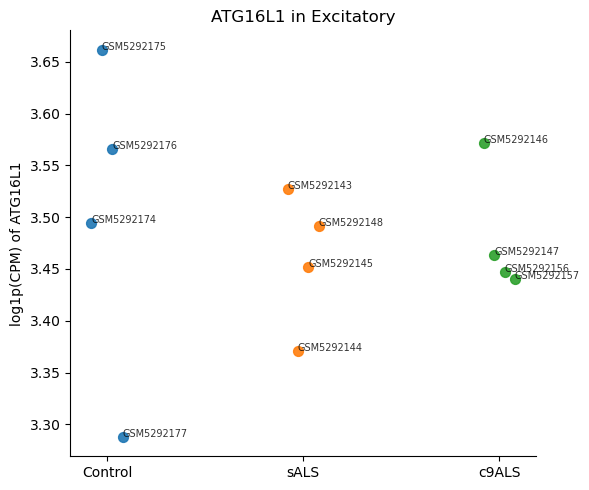

,condition,group_value,groupby_col,n_cells,expr
sample,,,,,
GSM5292143,sALS,Excitatory,cell_class_major_harmony,2092,3.527508
GSM5292144,sALS,Excitatory,cell_class_major_harmony,1318,3.371208
GSM5292145,sALS,Excitatory,cell_class_major_harmony,152,3.451752
GSM5292146,c9ALS,Excitatory,cell_class_major_harmony,2315,3.571522
GSM5292147,c9ALS,Excitatory,cell_class_major_harmony,2844,3.463536
GSM5292148,sALS,Excitatory,cell_class_major_harmony,700,3.491610
GSM5292156,c9ALS,Excitatory,cell_class_major_harmony,1346,3.447335
GSM5292157,c9ALS,Excitatory,cell_class_major_harmony,2352,3.440467
GSM5292174,Control,Excitatory,cell_class_major_harmony,749,3.494033


In [18]:
plot_gene_by_condition(
    adata_merged_pb,
    gene="ATG16L1",
    group_value="Excitatory",
    groupby_col="cell_class_major_harmony",
    min_cells_per_sample=20,
)


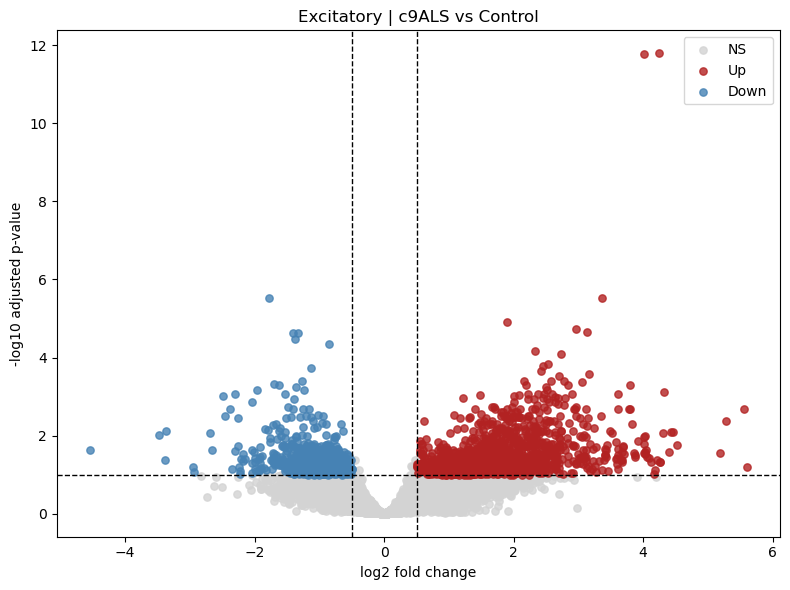

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,group_name,comparison,neglog10_padj,sig
0,19.175522,0.581364,0.505417,1.150266,2.500344e-01,6.277042e-01,TNFRSF4,Excitatory,Control_vs_c9ALS,0.202245,NS
1,42.261174,-1.046802,0.412623,-2.536944,1.118249e-02,1.315157e-01,TNFRSF18,Excitatory,Control_vs_c9ALS,0.881022,NS
2,431.618092,-0.444524,0.200614,-2.215818,2.670398e-02,2.119659e-01,ATAD3B,Excitatory,Control_vs_c9ALS,0.673734,NS
4,38.120461,-0.179600,0.299956,-0.598755,5.493362e-01,8.471434e-01,ENSG00000234396,Excitatory,Control_vs_c9ALS,0.072043,NS
5,6.691392,-1.089054,0.768974,-1.416242,1.567047e-01,5.101494e-01,MTND1P23,Excitatory,Control_vs_c9ALS,0.292303,NS
...,...,...,...,...,...,...,...,...,...,...,...
61519,64.509913,4.247964,0.508094,8.360585,6.240824e-17,1.611942e-12,ENSG00000276256,Excitatory,Control_vs_c9ALS,11.792650,Up
61524,1567.198745,0.194439,0.415051,0.468470,6.394488e-01,8.886332e-01,ENSG00000273748,Excitatory,Control_vs_c9ALS,0.051277,NS
61529,92.621289,-0.557954,0.384885,-1.449664,1.471522e-01,4.958636e-01,ENSG00000278817,Excitatory,Control_vs_c9ALS,0.304638,NS
61537,40.112760,-0.459978,0.581944,-0.790415,4.292852e-01,7.778800e-01,ENSG00000278384,Excitatory,Control_vs_c9ALS,0.109087,NS


In [9]:
plot_volcano(
    group_name="Excitatory",
    comparison="Control_vs_c9ALS",
)


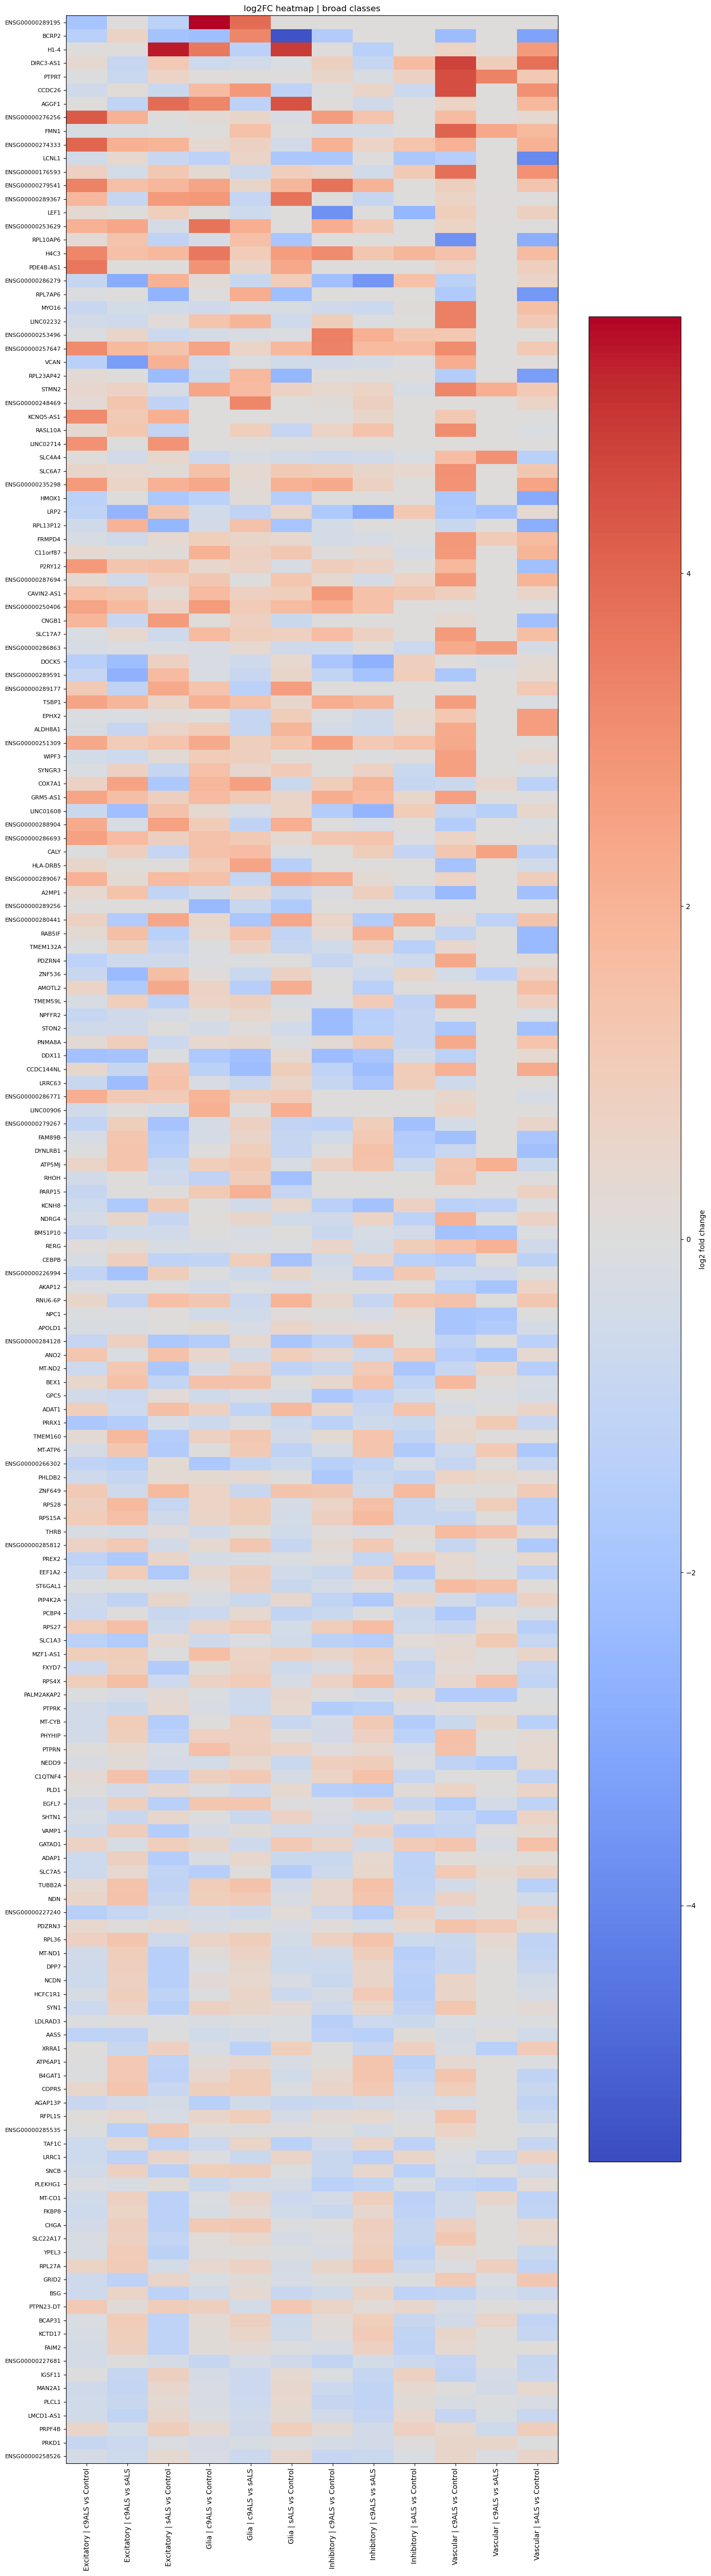

row,Excitatory | c9ALS vs Control,Excitatory | c9ALS vs sALS,Excitatory | sALS vs Control,Glia | c9ALS vs Control,Glia | c9ALS vs sALS,Glia | sALS vs Control,Inhibitory | c9ALS vs Control,Inhibitory | c9ALS vs sALS,Inhibitory | sALS vs Control,Vascular | c9ALS vs Control,Vascular | c9ALS vs sALS,Vascular | sALS vs Control
gene,,,,,,,,,,,,
ENSG00000289195,-1.927764,0.000000,-1.213404,5.539321,3.853629,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BCRP2,-1.313387,0.734377,-2.031099,-2.195048,3.204758,-5.353067,-1.585294,0.000000,0.000000,-2.262715,0.000000,-3.168469
H1-4,0.000000,0.000000,5.291709,3.572086,-1.290789,4.849109,0.000000,-1.335520,0.000000,0.652166,0.000000,2.713400
DIRC3-AS1,0.306080,-0.830700,1.143201,-0.633379,-0.490951,-0.146001,0.833370,-0.843077,1.677269,4.754723,0.983470,3.765785
PTPRT,-0.068290,-0.727688,0.666070,0.054537,0.011826,0.038750,0.551914,-0.218762,0.775183,4.475228,3.364303,1.158359
...,...,...,...,...,...,...,...,...,...,...,...,...
PLCL1,-0.476343,-0.752310,0.277463,-0.222918,-0.637151,0.415616,-0.887564,-1.023972,0.137445,-0.251133,-0.083495,-0.191627
LMCD1-AS1,-0.489983,-0.996121,0.517609,-0.169207,-0.460279,0.293649,-0.500121,-0.919858,0.422284,-0.924015,-0.170879,-0.798102
PRPF4B,0.576146,-0.377851,0.961835,0.350796,-0.561671,0.909206,0.289457,-0.515899,0.814852,0.391896,-0.597364,0.969347


In [10]:
plot_log2fc_heatmap(
    group_names=broad_main_classes,
    comparisons=["Control_vs_c9ALS", "Control_vs_sALS", "sALS_vs_c9ALS"],
    genes=None,
    top_n_per_result=20,
)

In [11]:
summarize_top_hits_all_genes(
    group_name="Glia",
    comparison="Control_vs_c9ALS",
    top_n=30,
)

,gene,log2FoldChange,padj,baseMean
44887,ENSG00000289195,5.539321,0.000218,26.752467
58466,LINC00906,2.119361,0.000272,103.581851
48026,ENSG00000287694,1.247388,0.000671,402.248983
47913,SLC7A5,-1.437842,0.000671,212.854349
21282,H4C3,3.621719,0.000671,182.652274
50098,ENSG00000266302,-1.763965,0.000750,369.691158
28550,ENSG00000253629,3.710565,0.000855,11.004430
7892,PTPRN,1.516601,0.001027,109.260680
33340,C11orf87,2.048418,0.001027,75.016614
27239,FRMPD4,0.949194,0.001087,333.142746


In [17]:
summarize_gene(
    gene="CALCOCO2",
    group_names=broad_main_classes,
    comparisons=["Control_vs_c9ALS", "Control_vs_sALS", "sALS_vs_c9ALS"],
)

,group_name,comparison,gene,log2FoldChange,padj,pvalue,baseMean
0,Excitatory,c9ALS vs Control,CALCOCO2,-0.241409,0.555839,0.189505,1279.973508
1,Excitatory,c9ALS vs sALS,CALCOCO2,-0.254860,0.266008,0.115843,1153.023359
2,Excitatory,sALS vs Control,CALCOCO2,0.020666,0.957595,0.905606,927.031352
3,Glia,c9ALS vs Control,CALCOCO2,-0.234718,0.681633,0.221422,751.325352
4,Glia,c9ALS vs sALS,CALCOCO2,-0.466133,0.370991,0.058185,1050.437497
5,Glia,sALS vs Control,CALCOCO2,0.231383,0.585743,0.262595,1230.163996
6,Inhibitory,c9ALS vs Control,CALCOCO2,-0.126109,0.824960,0.468816,149.808450
7,Inhibitory,c9ALS vs sALS,CALCOCO2,-0.330694,0.167783,0.047718,194.852733
8,Inhibitory,sALS vs Control,CALCOCO2,0.207398,0.512035,0.246951,136.679245
9,Vascular,c9ALS vs Control,CALCOCO2,-0.461888,0.969546,0.442535,17.358205
